# Homework 4

## Problem 1

:::{attention}  Problem Statement 
Climate modes are coherent, natural fluctuations in climate variables, such as temperature, rainfall, and wind speed. Many of them have significant impacts on the socioeconomic activities.

Describe two common methods that help identify and extract these modes from climate datasets.
Choose one climate mode that you think is important. Explain why it is important and briefly describe the physical mechanisms that help drive the mode.

:::

1. (a) Using anomolies. Climate anomolies are usually defined as the "delta", i.e.:
   
:::{prf:definition}
Let $X$ be a climate variable, it can be regard as a random variable. The corresponding anomoly is another random variable defined by:
\begin{equation}
X-\mathbb{E}[X]
\end{equation}
:::

Climate anomolies largely remove the noises from the climatology variations hence exposes the variation due to the climate mode itself. This method works perfectly for global modes like ENSO.
For more nuanced mode we might resort to more advanced techniques. 

(b) Power spectrum analysis; Regresion; 
After extracting the anomoly, we can further analze the data. Power spectrum analysis identifies the frequence and spectral energy of a mode, allowing us to relate the mode to specific ways of forcing. Regression by tree regression or SVM allows one to identify key components of the climate data the characterizes the mode. 

2. 
:::{tip}
I'll consider **ENSO**. It's importance is foreshadowed by it's fame. More specifically, due to telescoping, the entire climate system is regulated by this particualr cliamte mode. It has huge impact on the human society due to its relevance to extreme weather and strong impacts on local weather system
:::
   
   ENSO oscillates between 1. El Niño 2. La Niã 3. Neutral
   - Normally trade wind near equator blows from east to west displacing the warm surface sea water. As a result, upwelling can occur near south america. However during El Niño years, the trade wind weakens, as a result, upwelling stops. To make it worse the warm water in the West Pacific sloshes back toward South America forming the so-called **Kelvin Waves**. The warmer eastern pacific reduces the pressure gradient which further weakens the trade wind forming a positve feed back loop. 
   - La Niã is basically the opposite where the trade wind is stronger than usual. As a result there is more upwelling and strong pressure gradient hence even stronger trade wind.

## Problem 2

:::{attention} Problem Statement 
Q2 (1 pt). Simulations of future climate need to reply on assumptions on the socioeconomic pathways (e.g., SSPs). The projected climates can differ greatly between SSP scenarios.

Which of the following scenarios (SSP1-1.9, SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5) have the highest and the lowest greenhouse gas emissions?
What regions will experience the largest temperature increase? What regions will suffer the worst biodiversity and health outcomes? If they are not the same regions, explain why.
:::




1. Recall that the number after the hyphen stands for *radiative forcing level* with unit ($W/m^2$) by the time 2100. Therefore higher radiative forcing means more heat trapped hence stronger green house gas elimination. We can hence say SSP1-1.9 has lowest emission and SSP5-8.5 has the most.

2. The arctic region would experience largest tempearture increase due to arctic amplification. North america is also likely going to be heated up fast for similar reasons. Regions that is economically inferior is going to exprience the worst biodiversity and health outcomes, largely due to lower goverment mobility when it comes to mitigate these outcomes. Their need to maintain productivity to maintain the necessary level of economic actvity would also force them to further exploit natural resources and thus jeoperdizing biodiversity even more forming a positive feed back loop. 

## Problem 3

### (a) Correlation between Climate Indices

:::{attention} Problem Statement 
Calculate correlations among Nino 3.4, PDO, AMM, AMO, Hurricane Number, plus another two indices of your choice.
:::

Update: Some indices at NOAA/PSL website are out of maintenance. You can access hurricane number here: https://tropical.atmos.colostate.edu/Realtime/index.php?arch&loc=northatlantic 

In [3]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Next we compute the correlation matrix

In [4]:
hurricane = pd.read_csv("data/hurricane_number.csv", header=0, index_col=0,  sep='\\s+', engine='python')
hurricane_num = hurricane["Hurricanes"]
amm = (pd.read_csv("data/amm.csv", header=0, index_col=0,  sep='\\s+', engine='python')).mean(axis=1)
amo = (pd.read_csv("data/amo.csv", header=0, index_col=0,  sep='\\s+', engine='python')).mean(axis=1)
pdo = (pd.read_csv("data/pdo.csv", header=0, index_col=0,  sep='\\s+', engine='python')).mean(axis=1)
ao =  (pd.read_csv("data/ao.csv", header=0, index_col=0,  sep='\\s+', engine='python')).mean(axis=1)
enso_precip = (pd.read_csv("data/enso_precp.csv", header=0, index_col=0,  sep='\\s+', engine='python')).mean(axis=1)
nino = (pd.read_csv("data/nino3.4.csv", header=0, index_col=0,  sep='\\s+', engine='python')).mean(axis=1)
correlation = pd.DataFrame({"amm" : amm, "amo" : amo, "pdo" : pdo, "hurricane_num" : hurricane_num, "ao" : ao, "enso precipitatoin": enso_precip, "nino 3.4": nino}).dropna().corr()
print(correlation)

                         amm       amo       pdo  hurricane_num        ao  \
amm                 1.000000 -0.189768  0.288536      -0.005008  0.004650   
amo                -0.189768  1.000000 -0.272004       0.569140 -0.355524   
pdo                 0.288536 -0.272004  1.000000      -0.294670 -0.171069   
hurricane_num      -0.005008  0.569140 -0.294670       1.000000 -0.182270   
ao                  0.004650 -0.355524 -0.171069      -0.182270  1.000000   
enso precipitatoin  0.999418 -0.205527  0.308380      -0.026758  0.009275   
nino 3.4           -0.211950 -0.168143  0.498296      -0.425547  0.064576   

                    enso precipitatoin  nino 3.4  
amm                           0.999418 -0.211950  
amo                          -0.205527 -0.168143  
pdo                           0.308380  0.498296  
hurricane_num                -0.026758 -0.425547  
ao                            0.009275  0.064576  
enso precipitatoin            1.000000 -0.183894  
nino 3.4                  

We can visualize the result better using a heat map

Text(0.5, 1.0, 'Pearson Correlation Matrix Between Climate Indices')

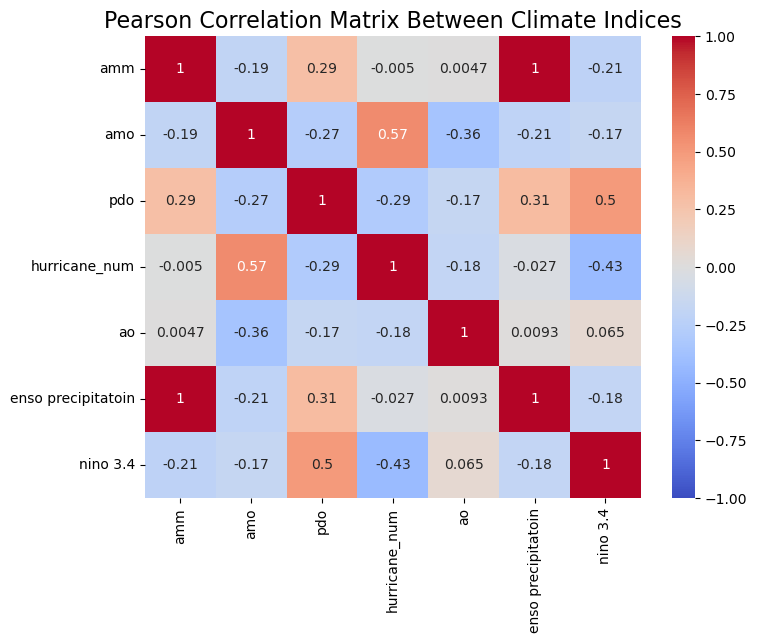

In [5]:
plt.figure(figsize=(8, 6)) # Adjust figure size as needed
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Pearson Correlation Matrix Between Climate Indices", fontsize=16, loc='center')

### (b) Climate Composite 

:::{attention} Problem Statement 
Work with one index and rank its values. Identify the years with most positive and most negative values. Plot climate composites using precipitation data
:::


:::{tip}
I'll choose **Nino 3.4** as my index.
:::

high nino index years [El Nino] 1948
1997    1.115000
1987    1.094167
1982    0.831667
2023    0.824167
1972    0.670000
2002    0.638333
1991    0.618333
1992    0.608333
1957    0.538333
2019    0.477500
dtype: float64
low nino index years [La Nina] 1948
1955   -1.445000
1950   -1.349167
1975   -1.316667
1999   -1.286667
1971   -1.236667
1974   -1.175833
1988   -0.999167
1956   -0.993333
2022   -0.936667
2000   -0.909167
dtype: float64


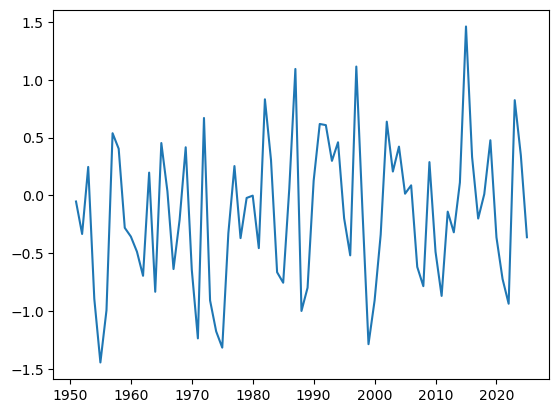

In [6]:
fig, ax = plt.subplots() 
ax.plot(nino.index[2:len(nino)-1], nino.to_numpy()[2:len(nino)-1])
nino_sorted=nino.sort_values()[2:-1]
print(f"high nino index years [El Nino] {nino_sorted[::-1][0:10]}")
print(f"low nino index years [La Nina] {nino_sorted[0:10:1]}")


Let's download the precipitation data that correspond to the lowest/highest *amm index* years.

In [ ]:
import cdsapi

dataset = "reanalysis-era5-single-levels-monthly-means"
request = {
    "product_type": ["monthly_averaged_reanalysis"],
    "variable": ["total_precipitation"],
    "year": [
       "1997", "1987", "1982", "2023", "1972", "2002", "1991", "1992", "1957", "2019",
       "1955", "1950", "1975", "1999", "1971", "1974", "1988", "1956", "2022", "2000"
    ],
    "month": [
        "12", "01", "02"
    ],
    "time": ["00:00"],
    "data_format": "grib",
    "download_format": "unarchived"
}

client = cdsapi.Client()
client.retrieve(dataset, request).download()


Again using my library **climavis**, we can do some visualization:

[Visualize-LOG] Directory 'output/El_nino_tp' already exists
[Visualize-LOG] Directory 'output/El_nino_tp/frame' already exists
[Visualize-LOG] Directory 'output/El_nino_tp/animation' already exists
[Visualize LOG] Plotting frame in scalar mode


100%|██████████| 1/1 [00:02<00:00,  2.28s/it]


[Visualize-LOG] Directory 'output/La_nina_tp' already exists
[Visualize-LOG] Directory 'output/La_nina_tp/frame' already exists
[Visualize-LOG] Directory 'output/La_nina_tp/animation' already exists
[Visualize LOG] Plotting frame in scalar mode


100%|██████████| 1/1 [00:02<00:00,  2.08s/it]


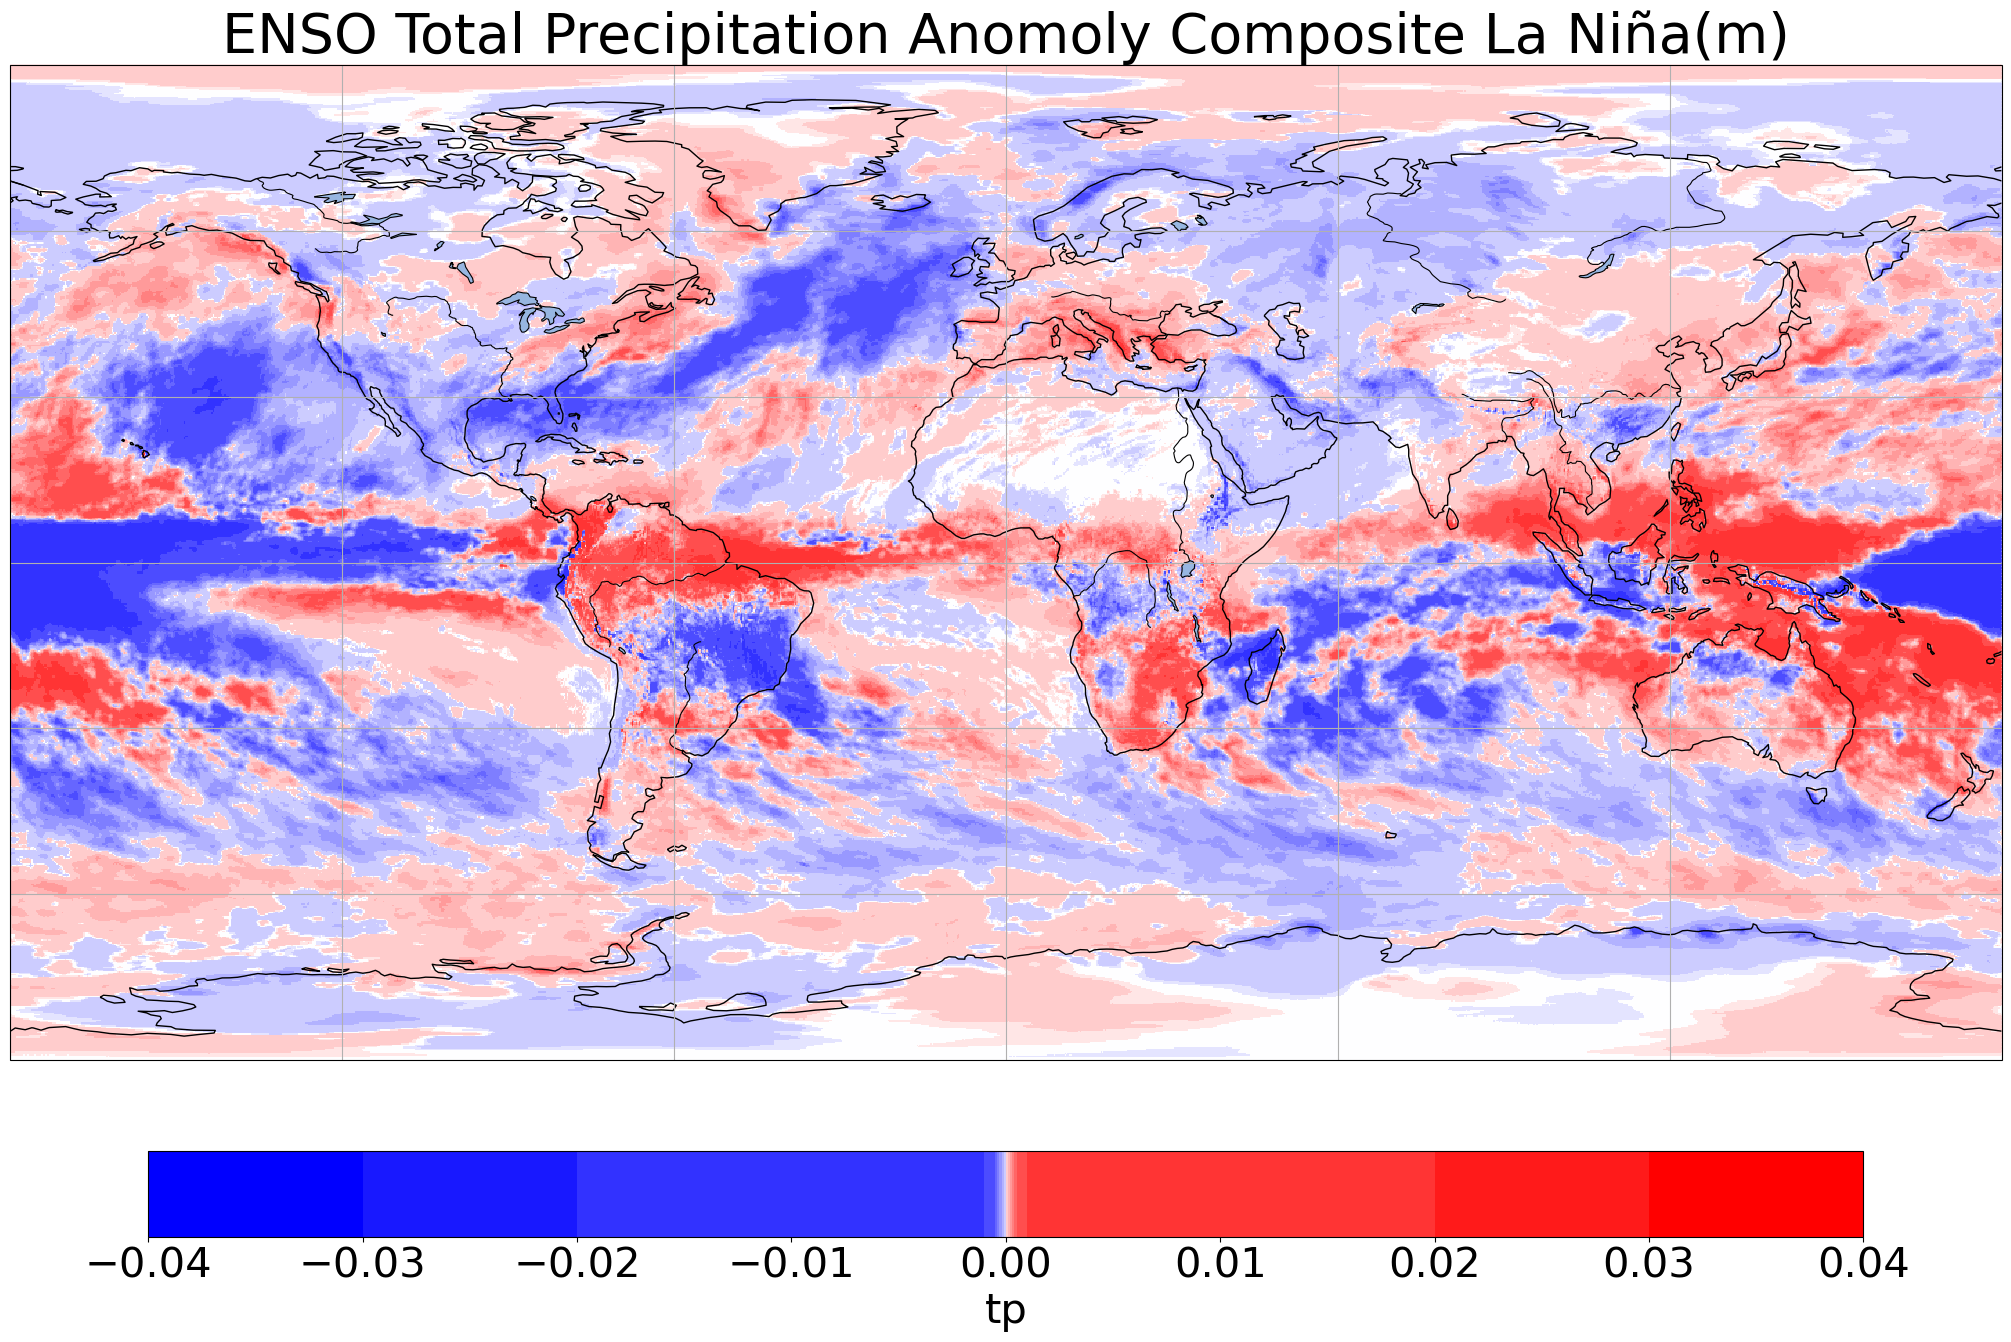

In [1]:
import climavis as cv
import numpy as np

data_path = {
    "tp" : "data/precipitation.grib" 
}

ds_tp = cv.DataSet("total precipitation", data_paths = data_path, time_steps=60, unit='m')

ds_tp.getAnomoly()

elnino = [1997,1987,1982, 2023, 1972, 2002, 1991, 1992, 1957,2019]
lanina = [1955, 1950, 1975, 1999, 1971, 1974, 1988, 1956, 2022, 2000]

ds_tp.averageOverTime(new_time_unit='years', new_time_steps=20)

elnino_tp, lanina_tp = ds_tp.groupByTimeGroup(group1 = elnino, group2=lanina, group1_name = "El Niño", group2_name = "La Niña", time_unit = 'years')

vis_param_elnino = {
    "task_name" : "El_nino_tp",
    "data_set" : elnino_tp, 
    "outputs_dir" : "output"
}

vis_param_lanina = {
    "task_name" : "La_nina_tp",
    "data_set" : lanina_tp, 
    "outputs_dir" : "output"
}

levels = np.array([-0.04, -0.03, -0.02,-0.001, -0.0005, -0.0004, -0.0003, -0.0002, -0.0001, -1e-5, -1e-5/2])
levels = np.concatenate([levels, -levels[::-1]])
vis = cv.Visualize(**vis_param_elnino)
vis.populate_frame(title="ENSO Total Precipitation Anomoly Composite", colormap='bwr', levels=levels)

vis = cv.Visualize(**vis_param_lanina)
vis.populate_frame(title="ENSO Total Precipitation Anomoly Composite", colormap='bwr', levels=levels)

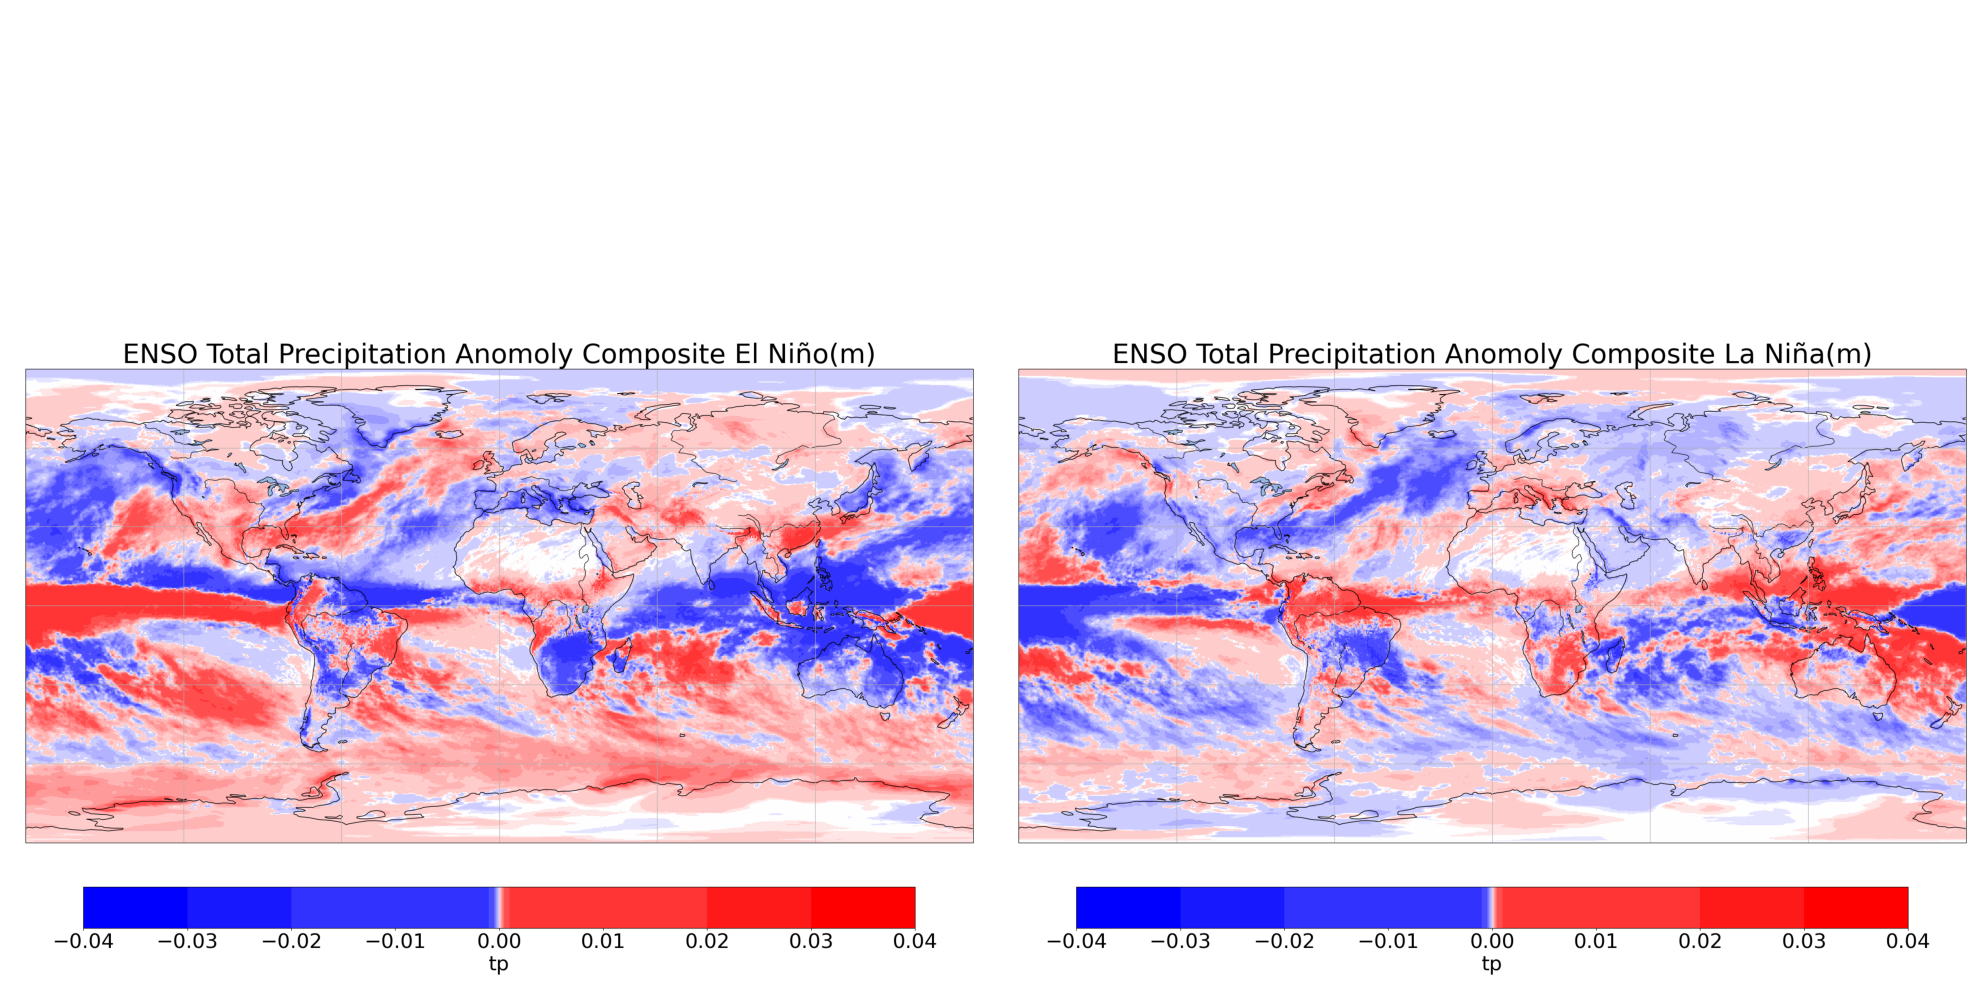

In [2]:
import matplotlib.image as mpimg 
import matplotlib.pyplot as plt

phase1 = mpimg.imread("output/El_nino_tp/frame/0.png")
phase2 = mpimg.imread("output/La_nina_tp/frame/0.png")

fig, ax = plt.subplots(1,2,figsize=(20,10))
ax[0].imshow(phase1)
ax[1].imshow(phase2)
ax[0].axis('off')
ax[1].axis('off')
plt.tight_layout()
plt.show()

It is clear there is a strong reversal in global precipitation anomly signal. If we look at the U.S as a "test case", the east coast is wetter than usual which is expected. The chraracteristic pattern comes from the thin drought stripe just above equaator in el nino years and a thicker stripe at the equator. The opposite patterns comes during la nina years. This is also correct behaviour. 